# ARCHS4 CRISPERCAS9 analysis


## Libraries

In [152]:
library(here)
library(dplyr)
library(here)
library(dplyr)
library(purrr)
library(fgsea)

## Input

In [153]:
archs4_CLAMPfull <- readRDS(here('output/archs4/archs4_CLAMP_C2CP.rds'))

In [154]:
archs4_CLAMPfull_Z <- data.frame(as.matrix(archs4_CLAMPfull$Z))

In [155]:
head(archs4_CLAMPfull_Z)

,LV1,LV2,LV3,LV4,LV5,LV6,LV7,LV8,LV9,LV10,⋯,LV2357,LV2358,LV2359,LV2360,LV2361,LV2362,LV2363,LV2364,LV2365,LV2366
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A1BG,0.0000000,1.0509984,0.0000000,0.2985388,0.0000000,0.5714278,0.6127143,0.5944296,0,0.7952836,⋯,0.0000000,0,0.5347975,0.0000000,0.0000000,0.4211271,0.0000000,0,0.0000000,0
A1BG-AS1,1.9011094,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0,0.5958653,⋯,0.0000000,0,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0,0.4578758,0
A2M,0.0000000,0.4719264,0.0000000,0.0000000,0.0000000,1.2559955,0.0000000,0.0000000,0,0.0000000,⋯,0.0000000,0,0.5786298,0.3801813,0.0000000,0.4137119,0.0000000,0,0.0000000,0
A2M-AS1,0.0000000,0.9193645,0.0000000,0.0000000,0.0000000,1.1325443,0.0000000,0.0000000,0,0.0000000,⋯,0.0000000,0,0.0000000,1.1173294,0.0000000,1.6189121,0.8019834,0,0.6508802,0
A2ML1,0.4316016,1.4136527,0.7068578,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0,0.0000000,⋯,0.0000000,0,0.3251179,0.0000000,0.4183108,0.0000000,0.0000000,0,0.0000000,0
A4GALT,1.1382464,0.0000000,0.0000000,0.0000000,0.7452147,0.4756277,0.0000000,1.0645854,0,0.3666115,⋯,0.9000273,0,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0,0.0000000,0


In [156]:
archs4_CLAMPfull_summary <- data.frame(as.matrix(archs4_CLAMPfull$summary))

In [157]:
archs4_CLAMPfull_summary <- archs4_CLAMPfull_summary %>% 
dplyr::mutate(FDR = as.numeric(FDR)) %>%
dplyr::mutate(AUC = as.numeric(AUC))

In [158]:
head(archs4_CLAMPfull_summary)

,pathway,LV,AUC,p_value,FDR,npos,nneg
,<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>
C2CP490,C2CP_KEGG_VALINE_LEUCINE_AND_ISOLEUCINE_BIOSYNTHESIS,LV1,0.8483846,4.380020e-02,0.2534681,2,18293
C2CP558,C2CP_KEGG_MEDICUS_PATHOGEN_HIV_GP120_TO_TNF_NFKB_SIGNALING_PATHWAY,LV1,0.4931030,5.165405e-01,0.8211585,3,18293
C2CP1429,C2CP_REACTOME_ALPHA_LINOLENIC_OMEGA3_AND_LINOLEIC_OMEGA6_ACID_METABOLISM,LV1,0.4213634,6.501228e-01,0.8885062,2,18293
C2CP2265,C2CP_REACTOME_MITOCHONDRIAL_TRNA_AMINOACYLATION,LV1,0.7558219,3.804550e-02,0.2338726,4,18293
C2CP2395,C2CP_REACTOME_N_GLYCAN_ANTENNAE_ELONGATION,LV1,0.2248674,9.113549e-01,0.9501649,2,18293
C2CP2785,C2CP_REACTOME_SARS_COV_2_MODULATES_AUTOPHAGY,LV1,0.6557700,2.225136e-01,0.6432904,2,18293


In [159]:
archs4_CLAMPfull_summary_sig <- archs4_CLAMPfull_summary %>% 
dplyr::filter(FDR < 0.1) %>%
dplyr::filter(AUC > 0.6)

archs4_CLAMPfull_summary_sig %>% 
pull(LV) %>% 
unique() %>% 
length()

[1] 396

In [160]:
archs4_CLAMPfull <- NULL

## Output

In [161]:
output_dir <- here("output/crispr")
dir.create(output_dir, showWarnings = FALSE, recursive = TRUE)

## Lipids gene sets

In [162]:
lipid_deg <- read.csv(
  here("data/archs4/crispr_cas9/lipid_DEG.csv"),
  stringsAsFactors = FALSE
)

head(lipid_deg)

,gene_name,GFPLow_vs_UnSorted.log2FC,GFPLow_vs_UnSorted.FDR,GFPLow_vs_UnSorted.DEG,GFPHigh_vs_UnSorted.log2FC,GFPHigh_vs_UnSorted.FDR,GFPHigh_vs_UnSorted.DEG,GFPHigh_vs_GFPLow.log2FC,GFPHigh_vs_GFPLow.FDR,GFPHigh_vs_GFPLow.DEG,lipid.effect,rank
,<chr>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<lgl>,<chr>,<int>
1,ABCA2,0.55866839,0.116007580,FALSE,0.78491850,0.02712826,TRUE,0.2262501,0.632690747,FALSE,decrease *,-1
2,ABCB7,0.79852459,0.029219603,TRUE,-0.23834184,0.79077801,FALSE,-1.0368664,0.000693259,TRUE,increase **,2
3,ABCE1,0.68407544,0.047833353,TRUE,0.04432565,0.97525531,FALSE,-0.6397498,0.049228517,TRUE,increase **,2
4,ABCG2,0.43812607,0.049607475,TRUE,0.37554996,0.22953855,FALSE,-0.0625761,0.883677774,FALSE,increase *,1
5,ABHD10,-0.64140454,0.009845648,TRUE,-0.24194344,0.65855335,FALSE,0.3994611,0.156967126,FALSE,decrease *,-1
6,ABHD13,0.08890522,0.806738313,FALSE,-0.45420696,0.04021766,TRUE,-0.5431122,0.000576641,TRUE,increase **,2


In [163]:
orig_deg_gene_sets <- list()
for (r in unique(lipid_deg$rank)) {
  if (r == 0) next
  genes <- lipid_deg$gene_name[lipid_deg$rank == r]
  orig_deg_gene_sets[[paste0("gene_set_", r)]] <- genes
}

In [164]:
length(orig_deg_gene_sets)

[1] 6

## Combine gene sets into "increase lipids" and "decrease lipids"

In [165]:
deg_gene_sets <- list()

In [166]:
# genes that increase lipids
deg_gene_sets[["gene_set_increase"]] <- c(
  #     orig_deg_gene_sets[["gene_set_2"]],
  orig_deg_gene_sets[["gene_set_3"]]
)

In [167]:
# genes that decrease lipids
deg_gene_sets[["gene_set_decrease"]] <- c(
  #     orig_deg_gene_sets[["gene_set_-2"]],
  orig_deg_gene_sets[["gene_set_-3"]]
)

In [168]:
length(deg_gene_sets)

[1] 2

In [169]:
stopifnot(length(deg_gene_sets[["gene_set_increase"]]) == 6)

In [170]:
length(deg_gene_sets[["gene_set_decrease"]])

[1] 8

In [171]:
stopifnot(length(deg_gene_sets[["gene_set_decrease"]]) == 8)

In [172]:
length(deg_gene_sets[["gene_set_increase"]])

[1] 6

In [173]:
# test new increase set
new_set <- deg_gene_sets[["gene_set_increase"]]
expected_set <- orig_deg_gene_sets[["gene_set_3"]]

stopifnot(length(new_set) == length(unique(new_set)))

stopifnot(
  length(new_set) ==
    length(
      intersect(
        new_set,
        expected_set
      )
    )
)

In [174]:
# test new decrease set
new_set <- deg_gene_sets[["gene_set_decrease"]]
expected_set <- orig_deg_gene_sets[["gene_set_-3"]]

stopifnot(length(new_set) == length(unique(new_set)))

stopifnot(
  length(new_set) ==
    length(
      intersect(
        new_set,
        expected_set
      )
    )
)
     

## Prepare LVs list

In [175]:
lvs <- list()
z_gene_names <- rownames(archs4_CLAMPfull_Z)

for (cidx in 1:ncol(archs4_CLAMPfull_Z)) {
  data <- archs4_CLAMPfull_Z[, cidx]
  names(data) <- z_gene_names

  lvs[[paste0("LV", cidx)]] <- data # [data > 0.0]
}

In [176]:
length(lvs)

[1] 2366

## Compute enrichment on all LVs

Since fgsea generates slightly different p-values across the same runs, here I run it 10 times for each LV/gene-set pair, and later I will take the maximum p-value. This is to avoid reproducibility/inconsistency problems.

In [177]:
n_reps <- 10
set.seed(0)

In [178]:
csv_path <- file.path(output_dir, "fgsea_hi_conf_all_lvs.csv")

if (file.exists(csv_path)) {
  message("fgsea results already exist — skipping loop.")
  results <- NULL
} else {
  results <- list()

  for (lv in names(lvs)) {
    repetitions <- list()

    for (i in 1:n_reps) {
      rep_res <- fgsea(pathways = deg_gene_sets, stats = lvs[[lv]], scoreType = "pos", eps = 0.0)[order(pval), ]
      rep_res[, "lv"] <- lv
      rep_res[, "rep_idx"] <- i

      repetitions[[i]] <- rep_res
    }

    res <- do.call(rbind, repetitions)

    results[[lv]] <- res
  }
}

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.07% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.07% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.07% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.07% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in preparePathwaysAndStats(p

In [179]:
length(results)

[1] 2366

In [180]:
if (is.null(results)) {
  df <- read.csv(csv_path, stringsAsFactors = FALSE)
} else {
  df <- do.call(rbind, results)
}

In [181]:
if (!is.null(results)) {
  df <- df %>% mutate(leadingEdge = map_chr(leadingEdge, toString))
}

In [182]:
dim(df)

[1] 47320    10

In [183]:
head(df)

pathway,pval,padj,log2err,ES,NES,size,leadingEdge,lv,rep_idx
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<chr>,<int>
gene_set_increase,0.08491508,0.1698302,0.150169802,0.7276577,1.3775022,5,"MBTPS1, ACACA, SCAP, HILPDA",LV1,1
gene_set_decrease,0.95804196,0.9580420,0.009547607,0.3200501,0.6543918,8,"BLCAP, PCYT2, PTEN, INSIG2, UBE2J2",LV1,1
gene_set_increase,0.08391608,0.1678322,0.151148761,0.7276577,1.3776325,5,"MBTPS1, ACACA, SCAP, HILPDA",LV1,2
gene_set_decrease,0.96103896,0.9610390,0.009185940,0.3200501,0.6552461,8,"BLCAP, PCYT2, PTEN, INSIG2, UBE2J2",LV1,2
gene_set_increase,0.07292707,0.1458541,0.163180127,0.7276577,1.3952626,5,"MBTPS1, ACACA, SCAP, HILPDA",LV1,3
gene_set_decrease,0.96303696,0.9630370,0.008938012,0.3200501,0.6672444,8,"BLCAP, PCYT2, PTEN, INSIG2, UBE2J2",LV1,3


In [184]:
df_sig <- df %>% 
dplyr::filter(padj < 0.1)

dim(df_sig)
head(df_sig)

[1] 629  10

pathway,pval,padj,log2err,ES,NES,size,leadingEdge,lv,rep_idx
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<chr>,<int>
gene_set_decrease,0.04995005,0.09990010,0.1999152,0.9766495,1.367536,8,"UBE2J2, PCYT2",LV13,4
gene_set_increase,0.04595405,0.09190809,0.2089550,0.9829515,1.800988,5,DGAT2,LV31,2
gene_set_increase,0.04295704,0.08591409,0.2165428,0.9829515,1.873558,5,DGAT2,LV31,5
gene_set_increase,0.04895105,0.09790210,0.2020717,0.9829515,1.947014,5,DGAT2,LV31,8
gene_set_decrease,0.04095904,0.08191808,0.2220560,0.9916373,1.603783,8,SOX9,LV37,1
gene_set_decrease,0.02027652,0.04055303,0.3524879,0.9916373,1.643989,8,SOX9,LV37,2


## Save

In [185]:
if (!is.null(results)) {
  write.csv(df, csv_path, row.names = FALSE)
}

# Pathways

In [186]:
df_sig_sub <- df_sig %>% 
dplyr::select(lv, pathway, leadingEdge)

colnames(df_sig_sub) <- c("LV", "pathway_lipids", "leadingEdge")

head(df_sig_sub)

LV,pathway_lipids,leadingEdge
<chr>,<chr>,<chr>
LV13,gene_set_decrease,"UBE2J2, PCYT2"
LV31,gene_set_increase,DGAT2
LV31,gene_set_increase,DGAT2
LV31,gene_set_increase,DGAT2
LV37,gene_set_decrease,SOX9
LV37,gene_set_decrease,SOX9


In [187]:
lv_sig_sub <- df_sig_sub[, c('LV')] %>% unique() %>% pull()
lv_sig_sub
length(lv_sig_sub)

[1] "LV13"   "LV31"   "LV37"   "LV40"   "LV51"   "LV54"   "LV62"   "LV75"  
 [9] "LV79"   "LV95"   "LV96"   "LV149"  "LV156"  "LV162"  "LV175"  "LV176" 
[17] "LV177"  "LV210"  "LV256"  "LV260"  "LV299"  "LV329"  "LV330"  "LV345" 
[25] "LV350"  "LV365"  "LV384"  "LV388"  "LV389"  "LV435"  "LV492"  "LV507" 
[33] "LV508"  "LV510"  "LV523"  "LV527"  "LV534"  "LV540"  "LV541"  "LV605" 
[41] "LV692"  "LV698"  "LV718"  "LV748"  "LV758"  "LV762"  "LV778"  "LV796" 
[49] "LV902"  "LV946"  "LV958"  "LV976"  "LV989"  "LV1017" "LV1024" "LV1027"
[57] "LV1034" "LV1093" "LV1107" "LV1131" "LV1148" "LV1175" "LV1217" "LV1307"
[65] "LV1321" "LV1343" "LV1351" "LV1361" "LV1376" "LV1395" "LV1430" "LV1440"
[73] "LV1453" "LV1520" "LV1522" "LV1584" "LV1602" "LV1745" "LV1746" "LV1888"
[81] "LV1890" "LV1891" "LV1971" "LV2068" "LV2077" "LV2121" "LV2222" "LV2262"
[89] "LV2310"

[1] 89

In [188]:
head(archs4_CLAMPfull_summary_sig)

,pathway,LV,AUC,p_value,FDR,npos,nneg
,<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>
C2CP426,C2CP_KEGG_OLFACTORY_TRANSDUCTION,LV2,0.8714810,5.321509e-05,0.0033284080,9,18325
C2CP2400,C2CP_REACTOME_OLFACTORY_SIGNALING_PATHWAY,LV2,0.7845332,4.422501e-03,0.0918663400,7,18325
C2CP615,C2CP_KEGG_MEDICUS_REFERENCE_26S_PROTEASOME_MEDIATED_PROTEIN_DEGRADATION,LV4,0.9359188,2.835909e-05,0.0019307130,7,18267
C2CP1089,C2CP_KEGG_MEDICUS_VARIANT_MUTATION_CAUSED_ABERRANT_HTT_TO_26S_PROTEASOME_MEDIATED_PROTEIN_DEGRADATION,LV4,0.9280201,3.857055e-05,0.0024960660,7,18267
C2CP1106,C2CP_KEGG_MEDICUS_VARIANT_MUTATION_CAUSED_ABERRANT_SNCA_TO_26S_PROTEASOME_MEDIATED_PROTEIN_DEGRADATION,LV4,0.9679438,7.736546e-06,0.0006416975,7,18267
C2CP1111,C2CP_KEGG_MEDICUS_VARIANT_MUTATION_CAUSED_ABERRANT_SOD1_TO_26S_PROTEASOME_MEDIATED_PROTEIN_DEGRADATION,LV4,0.9465019,5.206485e-06,0.0004717076,8,18267


In [189]:
sig_bp <- archs4_CLAMPfull_summary_sig %>% dplyr::filter(LV %in% lv_sig_sub)
sig_bp %>% 
group_by(LV) %>% 
summarize(
    pathway = paste0(pathway, collapse = '; '),
    .groups = 'drop'
)

LV,pathway
<chr>,<chr>
LV1175,C2CP_WP_17Q12_COPY_NUMBER_VARIATION_SYNDROME
LV1217,C2CP_PID_RHODOPSIN_PATHWAY
LV1395,C2CP_KEGG_MEDICUS_REFERENCE_WNT_SIGNALING_MODULATION_LGR_RSPO
LV1453,C2CP_PID_TOLL_ENDOGENOUS_PATHWAY; C2CP_REACTOME_IRAK4_DEFICIENCY_TLR2_4
LV1522,C2CP_REACTOME_BUTYROPHILIN_BTN_FAMILY_INTERACTIONS
LV156,C2CP_KEGG_MEDICUS_REFERENCE_MEVALONATE_PATHWAY; C2CP_REACTOME_CHOLESTEROL_BIOSYNTHESIS; C2CP_REACTOME_LANOSTEROL_BIOSYNTHESIS; C2CP_WP_CHOLESTEROL_BIOSYNTHESIS_PATHWAY; C2CP_WP_CHOLESTEROL_SYNTHESIS_DISORDERS; C2CP_WP_MEVALONATE_ARM_OF_CHOLESTEROL_BIOSYNTHESIS_PATHWAY
LV176,C2CP_PID_HIF1_TFPATHWAY
LV31,C2CP_REACTOME_FORMATION_OF_THE_CORNIFIED_ENVELOPE; C2CP_REACTOME_KERATINIZATION
LV330,C2CP_KEGG_CITRATE_CYCLE_TCA_CYCLE; C2CP_KEGG_MEDICUS_REFERENCE_BETA_OXIDATION; C2CP_KEGG_MEDICUS_REFERENCE_CITRATE_CYCLE_SECOND_CARBON_OXIDATION_2; C2CP_KEGG_MEDICUS_REFERENCE_ISOLEUCINE_DEGRADATION; C2CP_KEGG_MEDICUS_VARIANT_MUTATION_CAUSED_ABERRANT_ABETA_TO_CROSSTALK_BETWEEN_EXTRINSIC_AND_INTRINSIC_APOPTOTIC_PATHWAYS; C2CP_WP_TCA_CYCLE_AKA_KREBS_OR_CITRIC_ACID_CYCLE; C2CP_WP_TCA_CYCLE_AND_DEFICIENCY_OF_PYRUVATE_DEHYDROGENASE_COMPLEX_PDHC


# Traits

In [190]:
archs4_traits  <- readRDS(here('data/archs4/traits/archs4-phenoplier.rds'))

archs4_traits <- archs4_traits %>%
dplyr::select(!phenotype) %>%
rename(phenotype = phenotype_desc) %>% 
rename(LV = lv) %>%
rename(FDR = fdr)

head(archs4_traits)

,phenotype,LV,pvalue,FDR
,<fct>,<fct>,<dbl>,<dbl>
0,Coffee intake,LV903,1.150016e-09,5.632454e-06
1,Coffee intake,LV1788,3.166882e-09,1.431062e-05
2,Coffee intake,LV5,1.089045e-07,3.551048e-04
3,Coffee intake,LV1651,3.124974e-07,8.899242e-04
4,Coffee intake,LV617,6.411121e-07,1.654137e-03
5,Coffee intake,LV1067,1.583140e-06,3.519697e-03


In [191]:
archs4_traits_sig <- archs4_traits %>%
dplyr::filter(FDR < 0.05)

In [192]:
archs4_traits_sig %>%
dplyr::filter(LV %in% lv_sig_sub) %>% 
dplyr::select(LV, phenotype) %>% 
unique() %>% 
group_by(LV) %>% 
summarize(
    phenotype = paste0(phenotype, collapse = '; '),
    .groups = 'drop'
)

LV,phenotype
<fct>,<chr>
LV1024,"Pulse rate, automated reading"
LV1034,"Treatment/medication code: telmisartan (20003_1141166006); Diagnoses - main ICD10: I25 Chronic ischaemic heart disease; Ischaemic heart disease, wide definition; Treatment/medication code: reductil 10mg capsule (20003_1141174508); Coronary atherosclerosis"
LV1093,Number of cigarettes previously smoked daily
LV1107,"Diagnoses - main ICD10: M53 Other dorsopathies, not elsewhere classified; Other dorsopathies, not elsewhere classified"
LV1131,6mm strong meridian (left); 3mm strong meridian (left); 3mm weak meridian (right); Fibroblastic disorders; Palmar fascial fibromatosis [Dupuytren]; Job SOC coding: Retail and wholesale managers; 3mm weak meridian (left); 6mm weak meridian (left); Diagnoses - main ICD10: M72 Fibroblastic disorders; Illnesses of father: Prostate cancer; 6mm strong meridian (right); 6mm weak meridian (right); 3mm strong meridian (right)
LV1175,"Vascular/heart problems diagnosed by doctor: High blood pressure; Medication for cholesterol, blood pressure, diabetes, or take exogenous hormones: Blood pressure medication; Non-cancer illness code, self-reported: hypertension; Treatment/medication code: bendroflumethiazide (20003_1141194794); Medication for cholesterol, blood pressure or diabetes: Blood pressure medication; Vascular/heart problems diagnosed by doctor: None of the above; Job coding: residential manager, day care manager, nursing home manager, retirement home manager, convalescent home manager (22601_11853100)"
LV1217,Number of cigarettes previously smoked daily
LV13,Illnesses of father: Alzheimer's disease/dementia; Job SOC coding: Quality assurance managers; Illnesses of mother: Alzheimer's disease/dementia
LV1307,Treatment/medication code: mesalazine (20003_1140865578); Other other unspecified disorders of the circulatory system


In [193]:
chol_alz_lvs <- archs4_traits_sig %>%
  dplyr::filter(LV %in% lv_sig_sub) %>% 
  dplyr::select(LV, phenotype) %>% 
  unique() %>% 
  group_by(LV) %>% 
  summarize(
    phenotype = paste0(phenotype, collapse = '; '),
    .groups = 'drop'
  ) %>%
  dplyr::filter(grepl("cholesterol|alzheimer", phenotype, ignore.case = TRUE))

chol_alz_lvs

LV,phenotype
<fct>,<chr>
LV1175,"Vascular/heart problems diagnosed by doctor: High blood pressure; Medication for cholesterol, blood pressure, diabetes, or take exogenous hormones: Blood pressure medication; Non-cancer illness code, self-reported: hypertension; Treatment/medication code: bendroflumethiazide (20003_1141194794); Medication for cholesterol, blood pressure or diabetes: Blood pressure medication; Vascular/heart problems diagnosed by doctor: None of the above; Job coding: residential manager, day care manager, nursing home manager, retirement home manager, convalescent home manager (22601_11853100)"
LV13,Illnesses of father: Alzheimer's disease/dementia; Job SOC coding: Quality assurance managers; Illnesses of mother: Alzheimer's disease/dementia
LV156,"Haematocrit percentage; Skin colour; Illnesses of siblings: High blood pressure; Vascular/heart problems diagnosed by doctor: High blood pressure; Relative age of first facial hair; Medication for cholesterol, blood pressure, diabetes, or take exogenous hormones: Blood pressure medication; Non-cancer illness code, self-reported: hypertension; Treatment/medication code: bendroflumethiazide (20003_1141194794); Hair colour (natural, before greying): Light brown; Medication for cholesterol, blood pressure, diabetes, or take exogenous hormones: None of the above; Noisy workplace; Diastolic blood pressure, automated reading; Hair colour (natural, before greying): Red; Vascular/heart problems diagnosed by doctor: None of the above; Diagnoses - main ICD10: I83 Varicose veins of lower extremities; Diseases of veins, lymphatic vessels and lymph nodes, not elsewhere classified; Hair colour (natural, before greying): Dark brown; Illnesses of siblings: None of the above (group 1)"
LV175,"Illnesses of father: Alzheimer's disease/dementia; Illnesses of siblings: Alzheimer's disease/dementia; Diagnoses - main ICD10: C50 Malignant neoplasm of breast; Malignant neoplasm of breast; Illnesses of mother: Alzheimer's disease/dementia; Medication for cholesterol, blood pressure, diabetes, or take exogenous hormones: Cholesterol lowering medication; Non-cancer illness code, self-reported: high cholesterol"
LV976,"Blood clot, DVT, bronchitis, emphysema, asthma, rhinitis, eczema, allergy diagnosed by doctor: Blood clot in the lung; Non-cancer illness code, self-reported: deep venous thrombosis (dvt); Type 1 diabetes with ophthalmic complications; Non-cancer illness code, self-reported: adrenocortical insufficiency/addison's disease; Endocrine, nutritional and metabolic diseases; Malignant neoplasm of anus and anal canal; Eye problems/disorders: Diabetes related eye disease; Diagnoses - main ICD10: E14 Unspecified diabetes mellitus; Medication for cholesterol, blood pressure, diabetes, or take exogenous hormones: Insulin; Illnesses of siblings: Diabetes; Non-cancer illness code, self-reported: type 1 diabetes; Type 1 diabetes; Age diabetes diagnosed; Type 1 diabetes without complications; Treatment/medication code: insulin product (20003_1140883066); DVT of lower extremities and pulmonary embolism; Medication for cholesterol, blood pressure or diabetes: Insulin; Started insulin within one year diagnosis of diabetes; Diagnoses - main ICD10: E10 Insulin-dependent diabetes mellitus; Diagnoses - main ICD10: C21 Malignant neoplasm of anus and anal canal; Blood clot, DVT, bronchitis, emphysema, asthma, rhinitis, eczema, allergy diagnosed by doctor: Blood clot in the leg (DVT); Type 1 diabetes with ketoacidosis; Diagnoses - main ICD10: I12 Hypertensive renal disease; Venous thromboembolism; Diabetic ketoacidosis"


In [194]:
chol_alz_lvs$LV

[1] LV1175 LV13   LV156  LV175  LV976 
2366 Levels: LV1 LV10 LV100 LV1000 LV1001 LV1002 LV1003 LV1004 LV1005 ... LV999

In [195]:
archs4_CLAMPfull_summary_sig %>% dplyr::filter(LV %in% chol_alz_lvs$LV)

,pathway,LV,AUC,p_value,FDR,npos,nneg
,<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>
C2CP852,C2CP_KEGG_MEDICUS_REFERENCE_MEVALONATE_PATHWAY,LV156,0.9999728,4.305019e-03,9.125982e-02,2,18380
C2CP1580,C2CP_REACTOME_CHOLESTEROL_BIOSYNTHESIS,LV156,0.9996844,1.654495e-05,1.233332e-03,5,18380
C2CP2157,C2CP_REACTOME_LANOSTEROL_BIOSYNTHESIS,LV156,1.0000000,4.303211e-03,9.125982e-02,2,18380
C2CP33421,C2CP_WP_CHOLESTEROL_BIOSYNTHESIS_PATHWAY,LV156,1.0000000,6.461594e-04,2.579819e-02,3,18380
C2CP3347,C2CP_WP_CHOLESTEROL_SYNTHESIS_DISORDERS,LV156,0.9882481,8.388441e-04,3.097149e-02,3,18380
C2CP3721,C2CP_WP_MEVALONATE_ARM_OF_CHOLESTEROL_BIOSYNTHESIS_PATHWAY,LV156,0.9823721,5.627589e-03,9.380736e-02,2,18380
C2CP32043,C2CP_WP_17Q12_COPY_NUMBER_VARIATION_SYNDROME,LV1175,0.9874641,3.046037e-11,1.559836e-08,13,18286


In [196]:
pheno_info_path <- here('output/gtex/phenomexcan_simplified_phenotypes_info.tsv.gz')
pheno_info <- read.table(gzfile(pheno_info_path), header = TRUE, sep = '\t',
                         fill = TRUE, quote = "", comment.char = "")

pheno_info <- pheno_info %>%
  dplyr::mutate(n_eff = dplyr::coalesce(n, n_cases + n_controls))

desc_to_n <- pheno_info %>%
  dplyr::filter(!is.na(n_eff)) %>%
  dplyr::group_by(description) %>%
  dplyr::summarize(n_eff = max(n_eff, na.rm = TRUE), .groups = 'drop')

cat("Loaded", nrow(pheno_info), "phenotypes,", nrow(desc_to_n), "with n info\n")

Loaded 4091 phenotypes, 4035 with n info


In [225]:
library(ggplot2)
library(dplyr)
library(stringr)

pathway_data <- archs4_CLAMPfull_summary_sig %>%
  dplyr::filter(LV == "LV156") %>%
  dplyr::select(pathway, AUC, FDR) %>%
  mutate(
    neg_log10_FDR = -log10(pmax(FDR, 1e-10)),
    pathway_label = pathway %>%
      str_remove("^C2CP_") %>%
      str_remove("^REACTOME_") %>%
      str_remove("^KEGG_MEDICUS_REFERENCE_") %>%
      str_remove("^KEGG_") %>%
      str_remove("^WP_") %>%
      str_replace_all("_", " ") %>%
      str_to_title() %>%
      str_wrap(width = 45)
  ) %>%
  arrange(neg_log10_FDR) %>%
  mutate(pathway_label = factor(pathway_label, levels = pathway_label))

trait_data <- archs4_traits_sig %>%
  dplyr::filter(LV == "LV156") %>%
  left_join(desc_to_n, by = c("phenotype" = "description")) %>%
  mutate(
    neg_log10_FDR = -log10(pmax(FDR, 1e-10)),
    n_size = ifelse(is.na(n_eff), NA_real_, n_eff),
    trait_label = phenotype %>%
      str_replace_all("_", " ") %>%
      str_wrap(width = 45)
  ) %>%
  arrange(neg_log10_FDR) %>%
  mutate(trait_label = factor(trait_label, levels = trait_label))

neg_log10_fdr_label <- bquote(paste("-", log[10], "(FDR)"))
neg_log10_fdr_label_bold <- bquote(bold(paste("-", log[10], "(FDR)")))

shared_theme <- theme_minimal(base_size = 16) +
  theme(
    plot.background  = element_rect(fill = "white", colour = NA),
    panel.background = element_rect(fill = "white", colour = "#555555", linewidth = 0.5),
    panel.grid.major.x = element_line(colour = "#dddddd", linewidth = 0.3),
    panel.grid.major.y = element_blank(),
    panel.grid.minor = element_blank(),
    axis.text.y  = element_text(size = 14, colour = "grey15", hjust = 1),
    axis.text.x  = element_text(size = 14),
    axis.title.x = element_text(size = 13, margin = margin(t = 8)),
    axis.ticks.y = element_blank(),
    legend.position  = "bottom",
    legend.justification = "center",
    legend.title     = element_text(size = 10, face = "bold"),
    legend.text      = element_text(size = 9),
    legend.key       = element_rect(fill = "white", colour = NA),
    legend.box       = "horizontal",
    legend.margin    = margin(4, 8, 4, 8),
    legend.spacing.x = unit(0.8, "cm"),
    plot.margin = margin(10, 20, 10, 10)
  )

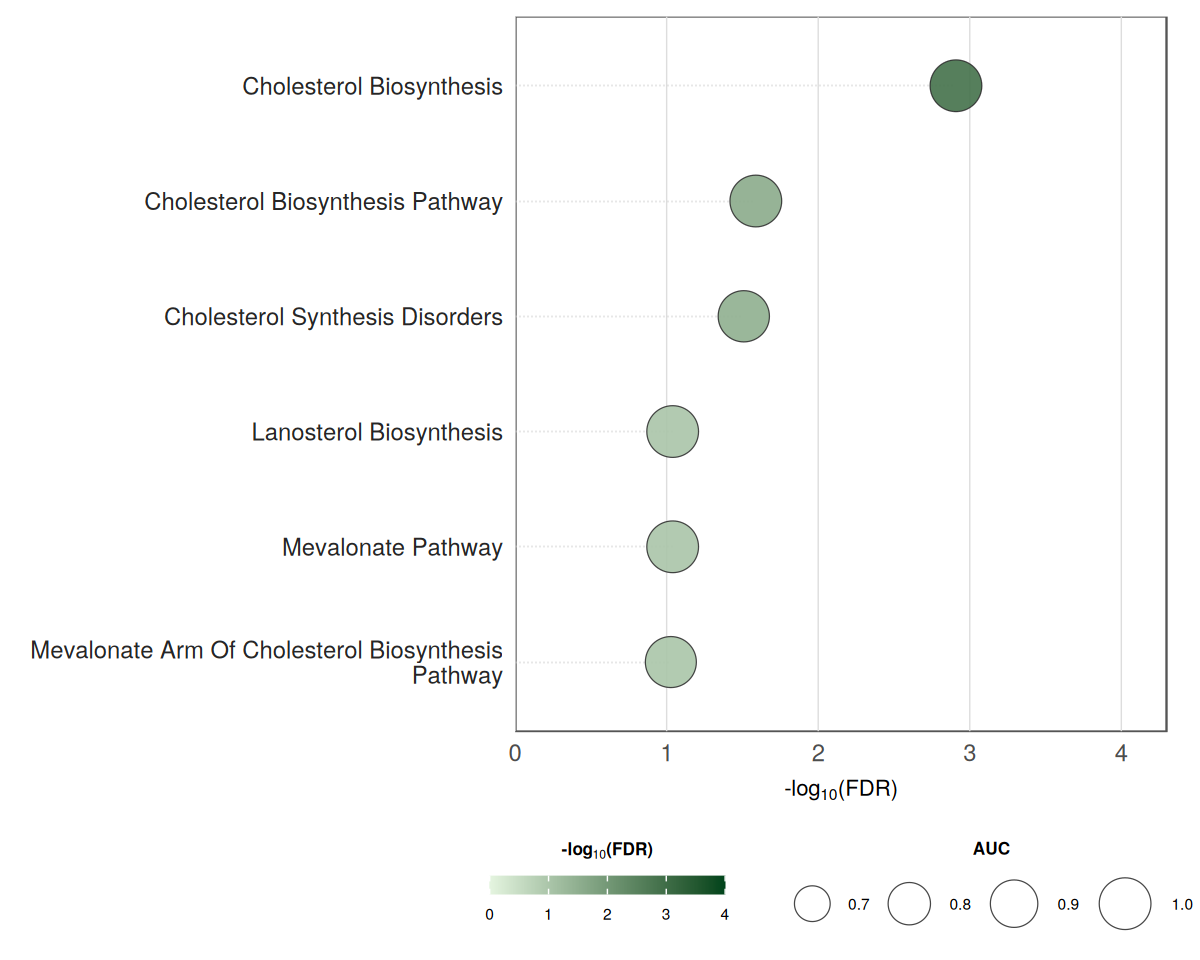

In [226]:
options(repr.plot.width = 10, repr.plot.height = 8)

fdr_max_pw <- 4

p <- ggplot(pathway_data, aes(x = neg_log10_FDR, y = pathway_label)) +
  geom_segment(
    aes(x = 0, xend = neg_log10_FDR, y = pathway_label, yend = pathway_label),
    colour = "#d0d0d0", linewidth = 0.4, linetype = "dotted"
  ) +
  geom_point(
    aes(size = AUC, fill = pmin(neg_log10_FDR, fdr_max_pw)),
    shape = 21, colour = "#333333", stroke = 0.4, alpha = 0.9
  ) +
  scale_fill_gradient(
    low = "#e5f5e0", high = "#00441b",
    limits = c(0, fdr_max_pw),
    breaks = seq(0, fdr_max_pw, by = 1),
    name = neg_log10_fdr_label_bold,
    guide = guide_colourbar(
      title.position = "top", title.hjust = 0.5,
      barwidth = unit(5, "cm"), barheight = unit(0.4, "cm"),
      ticks.linewidth = 0.3, order = 1
    )
  ) +
  scale_size_continuous(
    range = c(5, 14), limits = c(0.6, 1.0),
    breaks = c(0.7, 0.8, 0.9, 1.0), name = "AUC",
    guide = guide_legend(title.position = "top", title.hjust = 0.5, order = 2)
  ) +
  scale_x_continuous(
    limits = c(0, fdr_max_pw + 0.3),
    breaks = seq(0, fdr_max_pw, by = 1),
    expand = c(0, 0)
  ) +
  labs(x = neg_log10_fdr_label, y = NULL) +
  shared_theme

p

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


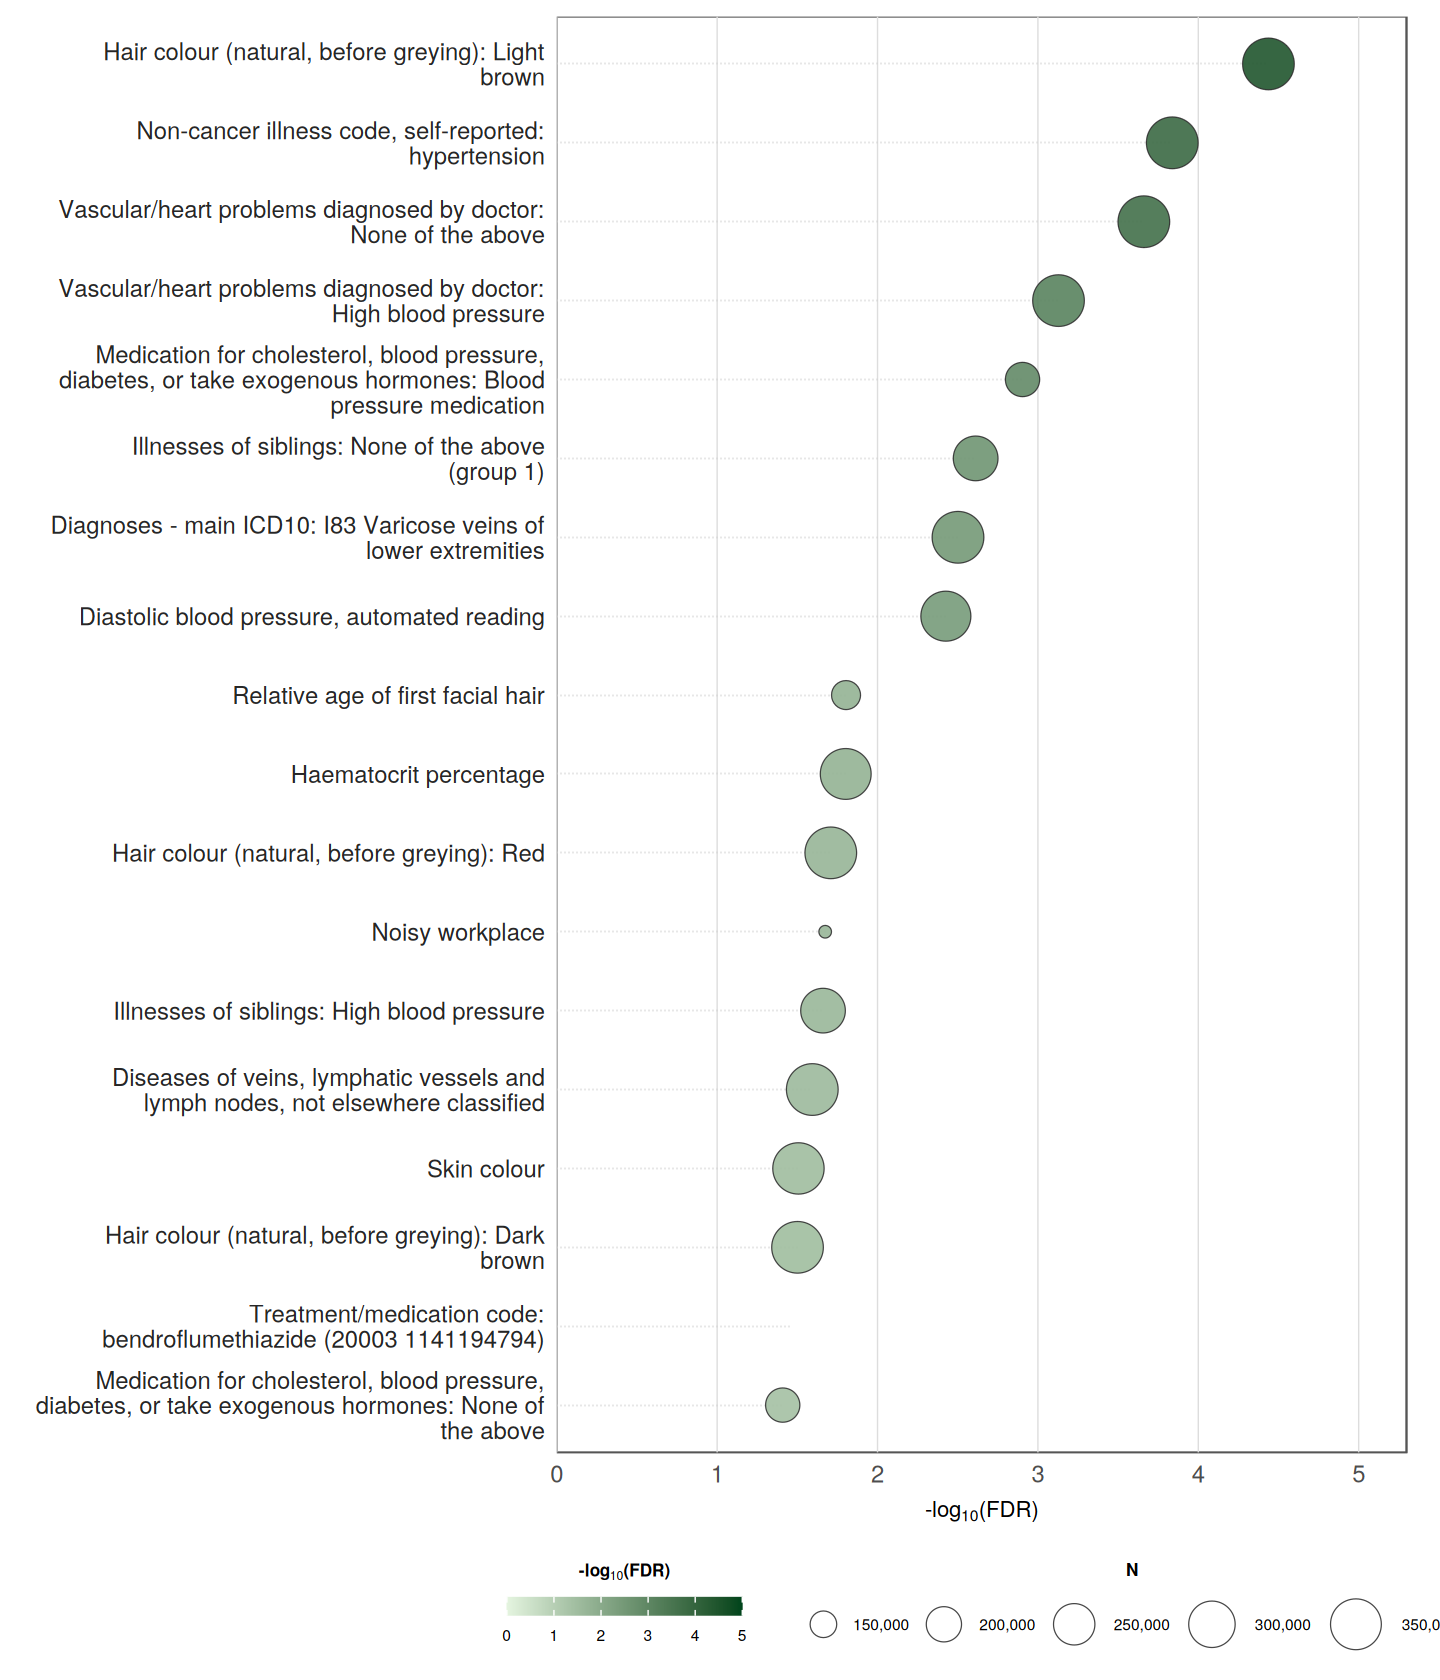

In [227]:
options(repr.plot.width = 12, repr.plot.height = 14)

fdr_max_tr <- ceiling(max(trait_data$neg_log10_FDR, na.rm = TRUE))
n_min <- min(trait_data$n_size, na.rm = TRUE)
n_max <- max(trait_data$n_size, na.rm = TRUE)

p2 <- ggplot(trait_data, aes(x = neg_log10_FDR, y = trait_label)) +
  geom_segment(
    aes(x = 0, xend = neg_log10_FDR, y = trait_label, yend = trait_label),
    colour = "#d0d0d0", linewidth = 0.4, linetype = "dotted"
  ) +
  geom_point(
    aes(size = n_size, fill = pmin(neg_log10_FDR, fdr_max_tr)),
    shape = 21, colour = "#333333", stroke = 0.4, alpha = 0.9
  ) +
  scale_fill_gradient(
    low = "#e5f5e0", high = "#00441b",
    limits = c(0, fdr_max_tr),
    breaks = seq(0, fdr_max_tr, by = 1),
    name = neg_log10_fdr_label_bold,
    guide = guide_colourbar(
      title.position = "top", title.hjust = 0.5,
      barwidth = unit(5, "cm"), barheight = unit(0.4, "cm"),
      ticks.linewidth = 0.3, order = 1
    )
  ) +
  scale_size_continuous(
    range = c(3, 14), limits = c(n_min, n_max),
    labels = scales::label_comma(),
    name = "N",
    guide = guide_legend(title.position = "top", title.hjust = 0.5, order = 2)
  ) +
  scale_x_continuous(
    limits = c(0, fdr_max_tr + 0.3),
    breaks = seq(0, fdr_max_tr, by = 1),
    expand = c(0, 0)
  ) +
  labs(x = neg_log10_fdr_label, y = NULL) +
  shared_theme

p2